In [1]:
# DATA EXPLORATORY ANALYSIS AND HYPOTHESIS TESTING FOR  INSURANCE CLAIMS DATA

In [150]:
# importing liabraries
import numpy as np
import pandas as pd

from datetime import datetime as dt

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import scipy.stats as stats


In [70]:
claim = pd.read_csv("C://projects/python/Case Study 3 - Insurance Claims Case Study/claims.csv")

In [9]:
demogs = pd.read_csv("C://projects/python/Case Study 3 - Insurance Claims Case Study/cust_demographics.csv")

In [72]:
claim

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No
...,...,...,...,...,...,...,...,...,...,...
1095,97727122,35951012,Other driver error,06/11/2017,Auto,No,Material only,$3059,4.0,Yes
1096,10247193,14818669,Natural causes,03/14/2018,Auto,No,Material only,$1520,2.0,No
1097,79807493,85322831,Other driver error,02/09/2018,Auto,No,Material and injury,$23575,2.0,Yes
1098,69299345,73449366,Other causes,03/21/2018,Auto,Unknown,Material and injury,$25120,1.0,No


In [13]:
demogs

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold
...,...,...,...,...,...,...
1080,79539873,Female,15-Mar-81,ND,459-425-4319,Platinum
1081,42364152,Female,07-Jul-96,ID,529-462-1635,Silver
1082,19888166,Male,11-Apr-90,WI,712-651-9613,Gold
1083,11256802,Female,22-Oct-64,LA,469-345-5617,Silver


In [74]:
claim.head()

,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
4,22890252,19269962,Crime,01/13/2018,Auto,No,Material only,$2680,1.0,No


In [19]:
demogs.head()

,CUST_ID,gender,DateOfBirth,State,Contact,Segment
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver
3,47830476,Female,01-May-86,MA,413-187-7945,Silver
4,19269962,Male,13-May-77,NV,956-871-8691,Gold


In [76]:
claims.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1100 entries, 0 to 1099
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   claim_id             1100 non-null   int64  
 1   customer_id          1100 non-null   int64  
 2   incident_cause       1100 non-null   object 
 3   claim_date           1100 non-null   object 
 4   claim_area           1100 non-null   object 
 5   police_report        1100 non-null   object 
 6   claim_type           1100 non-null   object 
 7   claim_amount         1035 non-null   object 
 8   total_policy_claims  1090 non-null   float64
 9   fraudulent           1100 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 86.1+ KB


In [23]:
demogs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   CUST_ID      1085 non-null   int64 
 1   gender       1085 non-null   object
 2   DateOfBirth  1085 non-null   object
 3   State        1085 non-null   object
 4   Contact      1085 non-null   object
 5   Segment      1085 non-null   object
dtypes: int64(1), object(5)
memory usage: 51.0+ KB


In [78]:
complete = pd.merge(demogs,claim,
                    left_on = 'CUST_ID',
                    right_on = 'customer_id',
                    how = 'inner')

In [27]:
complete

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,12-Jan-79,VT,789-916-8172,Platinum,54004764,21868593,Driver error,11/27/2017,Auto,No,Material only,$2980,1.0,No
1,75740424,Female,13-Jan-70,ME,265-543-1264,Silver,33985796,75740424,Crime,10/03/2018,Home,Unknown,Material only,$2980,3.0,No
2,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,53522022,30308357,Other driver error,02/02/2018,Auto,No,Material only,$3369.5,1.0,Yes
3,30308357,Female,11-Mar-84,TN,798-631-4758,Silver,63017412,30308357,Driver error,04/04/2018,Auto,No,Material only,$1950,6.0,No
4,47830476,Female,01-May-86,MA,413-187-7945,Silver,13015401,47830476,Natural causes,06/17/2018,Auto,No,Material only,$1680,1.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,79539873,Female,15-Mar-81,ND,459-425-4319,Platinum,62020796,79539873,Other driver error,09/06/2018,Auto,Yes,Material only,$1770,1.0,No
1081,42364152,Female,07-Jul-96,ID,529-462-1635,Silver,63269067,42364152,Other causes,05/09/2017,Home,No,Material only,$2800,1.0,No
1082,19888166,Male,11-Apr-90,WI,712-651-9613,Gold,22690595,19888166,Other driver error,05/15/2017,Auto,Yes,Injury only,$33080,2.0,No
1083,11256802,Female,22-Oct-64,LA,469-345-5617,Silver,12376894,11256802,Other driver error,04/18/2017,Auto,No,Material only,$2840,4.0,No


In [80]:
complete.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CUST_ID              1085 non-null   int64  
 1   gender               1085 non-null   object 
 2   DateOfBirth          1085 non-null   object 
 3   State                1085 non-null   object 
 4   Contact              1085 non-null   object 
 5   Segment              1085 non-null   object 
 6   claim_id             1085 non-null   int64  
 7   customer_id          1085 non-null   int64  
 8   incident_cause       1085 non-null   object 
 9   claim_date           1085 non-null   object 
 10  claim_area           1085 non-null   object 
 11  police_report        1085 non-null   object 
 12  claim_type           1085 non-null   object 
 13  claim_amount         1020 non-null   object 
 14  total_policy_claims  1075 non-null   float64
 15  fraudulent           1085 non-null   o

In [33]:
# Mismatch data type treatments

In [82]:
complete.DateOfBirth = pd.to_datetime(complete.DateOfBirth,format = '%d-%b-%y')

In [84]:
complete.claim_date = pd.to_datetime(complete.claim_date,format = '%m/%d/%Y')

In [86]:
complete

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent
0,21868593,Female,1979-01-12,VT,789-916-8172,Platinum,54004764,21868593,Driver error,2017-11-27,Auto,No,Material only,$2980,1.0,No
1,75740424,Female,1970-01-13,ME,265-543-1264,Silver,33985796,75740424,Crime,2018-10-03,Home,Unknown,Material only,$2980,3.0,No
2,30308357,Female,1984-03-11,TN,798-631-4758,Silver,53522022,30308357,Other driver error,2018-02-02,Auto,No,Material only,$3369.5,1.0,Yes
3,30308357,Female,1984-03-11,TN,798-631-4758,Silver,63017412,30308357,Driver error,2018-04-04,Auto,No,Material only,$1950,6.0,No
4,47830476,Female,1986-05-01,MA,413-187-7945,Silver,13015401,47830476,Natural causes,2018-06-17,Auto,No,Material only,$1680,1.0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,79539873,Female,1981-03-15,ND,459-425-4319,Platinum,62020796,79539873,Other driver error,2018-09-06,Auto,Yes,Material only,$1770,1.0,No
1081,42364152,Female,1996-07-07,ID,529-462-1635,Silver,63269067,42364152,Other causes,2017-05-09,Home,No,Material only,$2800,1.0,No
1082,19888166,Male,1990-04-11,WI,712-651-9613,Gold,22690595,19888166,Other driver error,2017-05-15,Auto,Yes,Injury only,$33080,2.0,No
1083,11256802,Female,2064-10-22,LA,469-345-5617,Silver,12376894,11256802,Other driver error,2017-04-18,Auto,No,Material only,$2840,4.0,No


In [43]:
# treatment on 'Contact' column

In [88]:
complete['Contact']

0       789-916-8172
1       265-543-1264
2       798-631-4758
3       798-631-4758
4       413-187-7945
            ...     
1080    459-425-4319
1081    529-462-1635
1082    712-651-9613
1083    469-345-5617
1084    182-385-1392
Name: Contact, Length: 1085, dtype: object

In [90]:
complete.Contact = complete.Contact.str.replace('-','')

In [92]:
complete.Contact

0       7899168172
1       2655431264
2       7986314758
3       7986314758
4       4131877945
           ...    
1080    4594254319
1081    5294621635
1082    7126519613
1083    4693455617
1084    1823851392
Name: Contact, Length: 1085, dtype: object

In [96]:
complete.Contact = complete.Contact.astype('Int64')

In [98]:
complete.Contact

0       7899168172
1       2655431264
2       7986314758
3       7986314758
4       4131877945
           ...    
1080    4594254319
1081    5294621635
1082    7126519613
1083    4693455617
1084    1823851392
Name: Contact, Length: 1085, dtype: Int64

In [100]:
complete['claim_amount'] = complete['claim_amount'].str.replace('$','')

In [102]:
complete['claim_amount'] = complete['claim_amount'].astype(float)

In [104]:
complete.claim_amount

0        2980.0
1        2980.0
2        3369.5
3        1950.0
4        1680.0
         ...   
1080     1770.0
1081     2800.0
1082    33080.0
1083     2840.0
1084     1490.0
Name: claim_amount, Length: 1085, dtype: float64

In [106]:
complete['flag'] = np.where(complete.police_report.isin(['No','Unknown']),0,1)

In [108]:
complete.flag

0       0
1       0
2       0
3       0
4       0
       ..
1080    1
1081    0
1082    1
1083    0
1084    0
Name: flag, Length: 1085, dtype: int32

In [110]:
complete = complete.sort_values('claim_date',ascending = False)

In [112]:
complete.reset_index(drop = True, inplace = True)

In [118]:
complete.drop_duplicates(subset = 'CUST_ID', inplace = True)

In [120]:
complete

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag
0,93915431,Male,2067-09-08,ME,1347851687,Gold,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.5,1.0,Yes,0
1,38011078,Female,1976-05-20,NE,2711231475,Gold,98795403,38011078,Crime,2018-10-30,Auto,Unknown,Material only,1940.0,1.0,No,0
2,58451506,Male,2068-04-22,FL,6735747823,Gold,43042986,58451506,Natural causes,2018-10-30,Auto,No,Material only,2420.0,1.0,No,0
3,46710738,Male,1977-04-28,MO,9628349361,Gold,74761374,46710738,Driver error,2018-10-30,Auto,No,Material only,1830.0,1.0,No,0
4,77510822,Female,1986-03-18,AK,4369347156,Silver,87329176,77510822,Other driver error,2018-10-30,Auto,Unknown,Material only,NaN,2.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1080,77219712,Female,1999-08-05,NH,6495928793,Platinum,61374372,77219712,Other causes,2017-01-01,Auto,No,Material and injury,20200.0,1.0,No,0
1081,42664554,Female,1993-08-13,TN,3969732531,Gold,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.0,1.0,No,0
1082,64840478,Female,1974-02-14,NM,9181747461,Silver,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.0,1.0,No,0
1083,74155265,Male,1985-11-16,TX,3927394873,Gold,25647821,74155265,Natural causes,2017-01-01,Auto,No,Material only,2080.0,1.0,No,0


In [122]:
(complete['CUST_ID'].value_counts() > 1).sum()

0

In [124]:
complete.claim_amount[complete.claim_amount.isna()] = complete.claim_amount.mean()

C:\Users\hp\AppData\Local\Temp\ipykernel_14376\262607298.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete.claim_amount[complete.claim_amount.isna()] = complete.claim_amount.mean()


In [128]:
complete.claim_amount.isna().sum()

0

In [130]:
complete.total_policy_claims[complete.total_policy_claims.isna()] = float(complete.total_policy_claims.mode())

C:\Users\hp\AppData\Local\Temp\ipykernel_14376\3210660765.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  complete.total_policy_claims[complete.total_policy_claims.isna()] = float(complete.total_policy_claims.mode())
C:\Users\hp\AppData\Local\Temp\ipykernel_14376\3210660765.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  complete.total_policy_claims[complete.total_policy_claims.isna()] = float(complete.total_policy_claims.mode())


In [132]:
complete.total_policy_claims.isna().sum()

0

In [134]:
complete['age'] = pd.Timestamp.now().year - complete.DateOfBirth.dt.year

In [136]:
complete.age

0      -42
1       49
2      -43
3       48
4       39
        ..
1080    26
1081    32
1082    51
1083    40
1084    31
Name: age, Length: 1078, dtype: int32

In [138]:
complete['Age_group'] = np.where(complete.age < 18,'Children',
                                 np.where(complete.age<=30,'Youth',
                                          np.where(complete.age<=60,'Adult','Senior')))

In [140]:
complete.Age_group

0       Children
1          Adult
2       Children
3          Adult
4          Adult
          ...   
1080       Youth
1081       Adult
1082       Adult
1083       Adult
1084       Adult
Name: Age_group, Length: 1078, dtype: object

In [142]:
complete.groupby('Segment').claim_amount.mean()

Segment
Gold        12846.400227
Platinum    12371.654843
Silver      12267.859374
Name: claim_amount, dtype: float64

In [158]:
cut_off = pd.to_datetime('2018-10-01') - pd.Timedelta(days = 20)

In [160]:
filtered_claims = complete[complete['claim_date'] <= cut_off]

In [166]:
total_claim = filtered_claims.groupby(by = ['incident_cause'])[['claim_amount']].sum()

In [168]:
total_claim

,claim_amount
incident_cause,
Crime,7.219386e+05
Driver error,3.315851e+06
Natural causes,1.312987e+06
Other causes,3.723152e+06
Other driver error,3.277536e+06


<Axes: xlabel='incident_cause'>

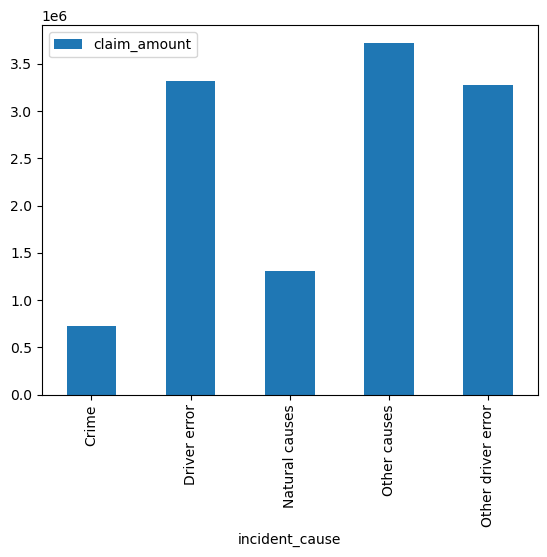

In [170]:
total_claim.plot(kind = 'bar')

In [211]:
p = complete[(complete.age>17) & complete.State.isin(['TX','DE','AK']) & complete.incident_cause.isin(['Driver error','Other  driver error'])]
p

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag,age,Age_group
95,39959491,Female,1995-04-07,DE,1397425417,Silver,54642809,39959491,Driver error,2018-09-06,Auto,Unknown,Material only,2720.000000,1.0,No,0,30,Youth
112,68772500,Male,1989-11-10,TX,5622595432,Silver,21550521,68772500,Driver error,2018-08-30,Auto,Unknown,Material only,2320.000000,1.0,No,0,36,Adult
171,65899365,Female,1973-07-25,TX,1359718567,Platinum,86096444,65899365,Driver error,2018-07-14,Auto,No,Material and injury,34160.000000,1.0,No,0,52,Adult
212,29903212,Male,1989-12-16,DE,2799183268,Platinum,7136079,29903212,Driver error,2018-06-17,Auto,No,Material only,2668.000000,2.0,Yes,0,36,Adult
321,84147585,Male,1972-10-18,AK,7435694783,Gold,78221963,84147585,Driver error,2018-04-10,Auto,Yes,Injury only,14430.000000,4.0,No,1,53,Adult
322,154557,Female,1978-05-23,DE,9628791238,Platinum,69348631,154557,Driver error,2018-04-10,Auto,No,Injury only,12501.726555,1.0,Yes,0,47,Adult
378,94643289,Male,1998-04-24,AK,3176121425,Silver,34596802,94643289,Driver error,2018-03-14,Auto,No,Material and injury,45287.000000,1.0,Yes,0,27,Youth
408,77006226,Female,1998-02-13,TX,6412955498,Platinum,21146312,77006226,Driver error,2018-02-15,Auto,No,Material only,2930.000000,1.0,No,0,27,Youth
475,13687085,Male,1997-11-18,DE,1371467356,Platinum,37688454,13687085,Driver error,2018-01-13,Auto,Unknown,Injury only,16760.000000,1.0,No,0,28,Youth
573,4669941,Male,1982-08-03,AK,7614623458,Platinum,70068,4669941,Driver error,2017-11-06,Auto,Unknown,Injury only,29900.000000,1.0,Yes,0,43,Adult


In [213]:
p.CUST_ID.count()

18

In [174]:
complete.Age_group.value_counts()

Age_group
Adult       692
Children    245
Youth       141
Name: count, dtype: int64

In [176]:
complete[(complete.Age_group == 'Adult') & complete.State.isin(['TX','DE','AK']) & complete.incident_cause.isin(['Driver error','Other driver error'])].CUST_ID.count()

24

In [198]:
x = complete[(complete.age > 17) & complete.State.isin(['TX','DE','AK'])]

In [200]:
y = x[(x['incident_cause'].isin(['Driver error','Other driver error']))]

In [202]:
y

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag,age,Age_group
4,77510822,Female,1986-03-18,AK,4369347156,Silver,87329176,77510822,Other driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,2.0,No,0,39,Adult
67,92971195,Male,1975-02-02,DE,8921734657,Gold,92399694,92971195,Other driver error,2018-09-26,Home,No,Material only,1140.000000,1.0,No,0,50,Adult
80,61810954,Male,1969-05-18,TX,7244936179,Silver,65335959,61810954,Other driver error,2018-09-19,Auto,Unknown,Material and injury,36620.000000,1.0,No,0,56,Adult
95,39959491,Female,1995-04-07,DE,1397425417,Silver,54642809,39959491,Driver error,2018-09-06,Auto,Unknown,Material only,2720.000000,1.0,No,0,30,Youth
112,68772500,Male,1989-11-10,TX,5622595432,Silver,21550521,68772500,Driver error,2018-08-30,Auto,Unknown,Material only,2320.000000,1.0,No,0,36,Adult
167,684748,Male,1977-08-03,AK,6133852863,Gold,7238381,684748,Other driver error,2018-07-14,Auto,No,Material only,2920.000000,2.0,No,0,48,Adult
171,65899365,Female,1973-07-25,TX,1359718567,Platinum,86096444,65899365,Driver error,2018-07-14,Auto,No,Material and injury,34160.000000,1.0,No,0,52,Adult
212,29903212,Male,1989-12-16,DE,2799183268,Platinum,7136079,29903212,Driver error,2018-06-17,Auto,No,Material only,2668.000000,2.0,Yes,0,36,Adult
273,2632562,Female,1985-12-14,AK,4985979658,Platinum,4506676,2632562,Other driver error,2018-05-14,Home,Unknown,Material only,1400.000000,1.0,No,0,40,Adult
321,84147585,Male,1972-10-18,AK,7435694783,Gold,78221963,84147585,Driver error,2018-04-10,Auto,Yes,Injury only,14430.000000,4.0,No,1,53,Adult


In [204]:
y.CUST_ID.count()

28

In [217]:
x = pd.pivot_table(complete, index = 'Segment',columns = 'gender',values = 'claim_amount')

In [233]:
x

gender,Female,Male
Segment,,
Gold,12339.441748,13279.849726
Platinum,12278.352777,12478.841145
Silver,11641.380032,12825.871029


<Figure size 1200x1000 with 0 Axes>

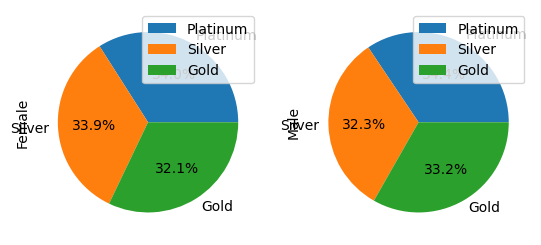

In [249]:
plt.figure(figsize = (12,10))
x.plot(kind = 'pie',
       labels = ['Platinum','Silver','Gold'],
       autopct = '%.1f%%',
       subplots = True
      )
# plt.figure(figsize = (10,7))
plt.show()

In [251]:
y = complete[(complete['incident_cause'].isin(['Driver error','Other driver error']))]
y

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag,age,Age_group
3,46710738,Male,1977-04-28,MO,9628349361,Gold,74761374,46710738,Driver error,2018-10-30,Auto,No,Material only,1830.000000,1.0,No,0,48,Adult
4,77510822,Female,1986-03-18,AK,4369347156,Silver,87329176,77510822,Other driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,2.0,No,0,39,Adult
6,40480522,Female,1984-05-30,NV,7392596835,Gold,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,0,41,Adult
7,28932340,Male,1996-01-05,LA,6522658231,Gold,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,0,29,Youth
9,86491727,Female,1997-01-29,IL,2941873286,Gold,32178193,86491727,Driver error,2018-10-30,Home,Unknown,Material only,1860.000000,1.0,No,0,28,Youth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,97514724,Male,1969-06-08,FL,6416847986,Platinum,97666948,97514724,Driver error,2017-01-01,Home,No,Injury only,19120.000000,1.0,No,0,56,Adult
1078,22756942,Male,1982-10-09,FL,4628233126,Silver,70512964,22756942,Driver error,2017-01-01,Auto,Yes,Injury only,20310.000000,1.0,No,1,43,Adult
1079,25634799,Female,1974-11-04,KS,7247813692,Platinum,36457152,25634799,Driver error,2017-01-01,Auto,No,Material only,2900.000000,2.0,No,0,51,Adult
1082,64840478,Female,1974-02-14,NM,9181747461,Silver,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,0,51,Adult


In [253]:
x = y.groupby(by = ['gender'])['claim_amount'].sum()
x

gender
Female    3.136718e+06
Male      3.975412e+06
Name: claim_amount, dtype: float64

<Axes: xlabel='gender'>

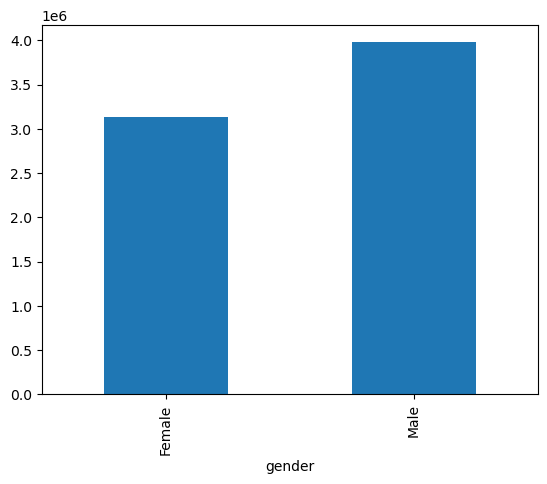

In [255]:
x.plot(kind = 'bar')

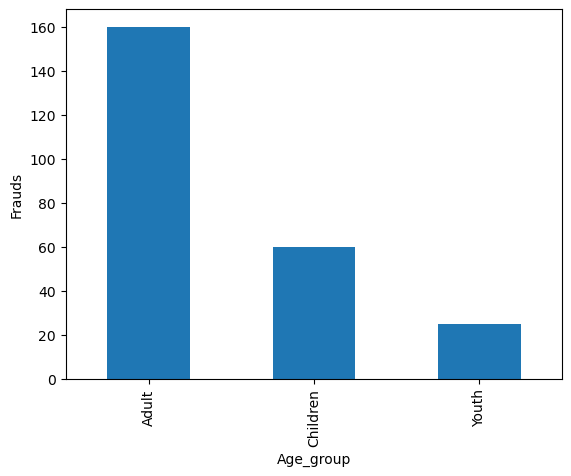

In [259]:
complete[complete.fraudulent == 'Yes'].groupby('Age_group').fraudulent.count().plot(kind = 'bar', ylabel = 'Frauds')
plt.show()

In [287]:
complete['Month_year'] = complete['claim_date'].dt.strftime("%Y-%B")

In [289]:
complete.sort_values(by = ['Month_year'],ascending = True)

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag,age,Age_group,Month_year
883,40591588,Male,1984-11-01,CA,6528375837,Silver,80286970,40591588,Driver error,2017-04-25,Auto,Unknown,Material and injury,39928.0,1.0,Yes,0,41,Adult,2017-April
913,98199694,Female,1978-04-04,GA,5623191874,Platinum,18265792,98199694,Driver error,2017-04-05,Auto,No,Material and injury,22540.0,1.0,No,0,47,Adult,2017-April
914,50771198,Male,1994-12-15,ND,3612497392,Silver,73337887,50771198,Other causes,2017-04-05,Auto,Yes,Material only,1020.0,1.0,No,1,31,Adult,2017-April
915,57043846,Male,1996-12-24,RI,7561974972,Silver,38818122,57043846,Other causes,2017-04-05,Auto,Yes,Injury only,34490.0,1.0,No,1,29,Youth,2017-April
916,55535045,Male,1994-08-11,AR,1645393948,Gold,95437929,55535045,Driver error,2017-04-05,Auto,No,Material only,1110.0,1.0,No,0,31,Adult,2017-April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78,58934617,Male,1990-04-01,CA,1578963619,Platinum,72555621,58934617,Other causes,2018-09-19,Auto,Yes,Injury only,27002.0,3.0,Yes,1,35,Adult,2018-September
80,61810954,Male,1969-05-18,TX,7244936179,Silver,65335959,61810954,Other driver error,2018-09-19,Auto,Unknown,Material and injury,36620.0,1.0,No,0,56,Adult,2018-September
81,90646435,Female,1978-12-07,IL,3569758315,Gold,84632427,90646435,Other causes,2018-09-19,Auto,Unknown,Injury only,25350.0,1.0,No,0,47,Adult,2018-September
83,91135917,Male,1986-08-15,NV,6971292549,Platinum,81102722,91135917,Other driver error,2018-09-12,Auto,No,Material only,2710.0,1.0,No,0,39,Adult,2018-September


In [291]:
x = complete.groupby(by = ['Month_year'])[['claim_amount']].sum().reset_index()

In [293]:
x

,Month_year,claim_amount
0,2017-April,747975.726555
1,2017-August,431616.453110
2,2017-December,694252.726555
3,2017-February,631456.453110
4,2017-January,608016.179664
5,2017-July,790868.906219
6,2017-June,560143.726555
7,2017-March,615576.453110
8,2017-May,546741.679664
9,2017-November,601187.453110


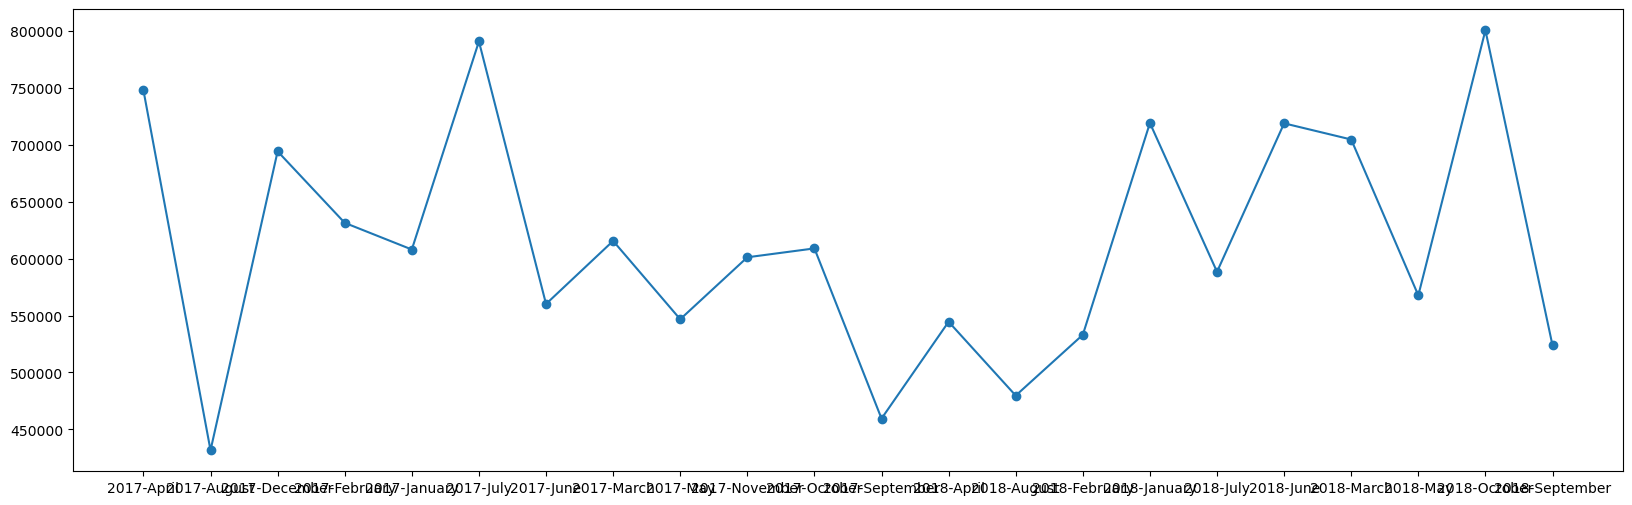

In [295]:
plt.figure(figsize = (20,6))
plt.plot( x['Month_year'].astype(str),
         x['claim_amount'],
        marker = 'o')

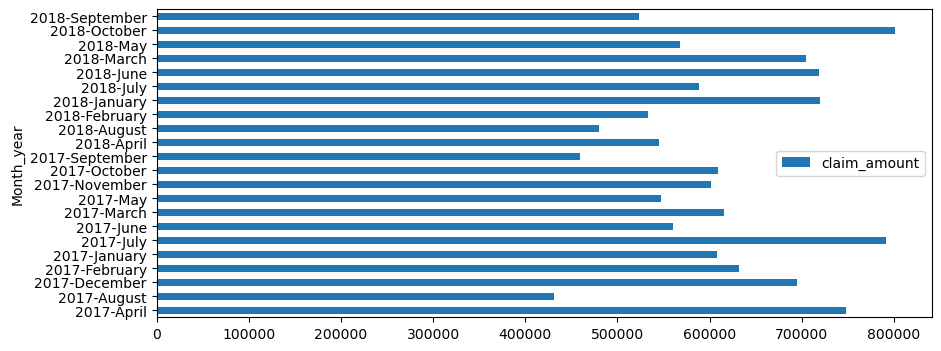

In [327]:
x.plot(kind = 'barh',
      x = 'Month_year',
      y = 'claim_amount',figsize = (10,4))
plt.show()

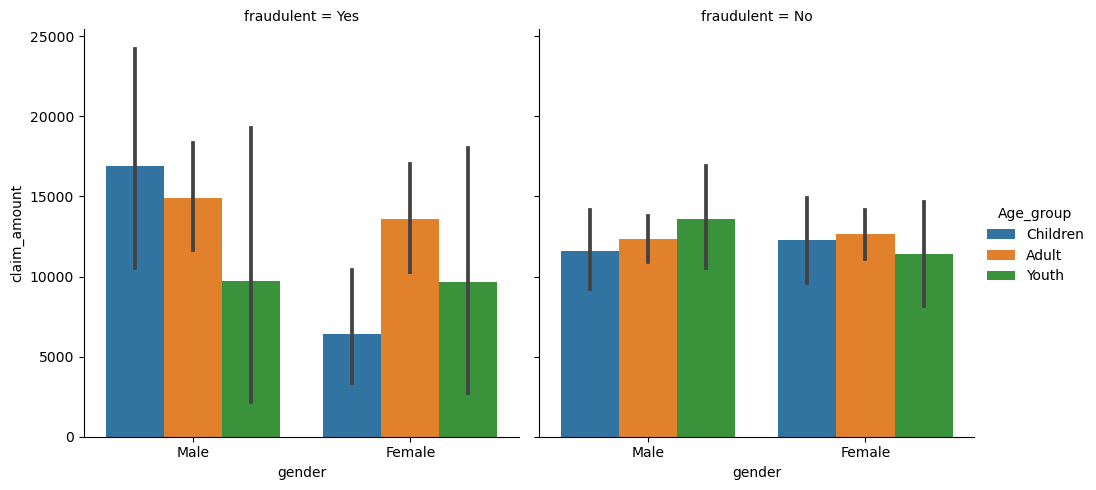

In [329]:
sns.catplot(data = complete,
            x = 'gender',
            y='claim_amount',
            hue='Age_group',
            col = 'fraudulent',
            kind = 'bar')
plt.show()

In [331]:
only_female = complete[(complete.gender == 'Female')]

In [333]:
only_female

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag,age,Age_group,Month_year
1,38011078,Female,1976-05-20,NE,2711231475,Gold,98795403,38011078,Crime,2018-10-30,Auto,Unknown,Material only,1940.000000,1.0,No,0,49,Adult,2018-October
4,77510822,Female,1986-03-18,AK,4369347156,Silver,87329176,77510822,Other driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,2.0,No,0,39,Adult,2018-October
5,17682060,Female,1974-11-21,NV,1861953465,Gold,49735712,17682060,Crime,2018-10-30,Home,Unknown,Material and injury,17020.000000,1.0,No,0,51,Adult,2018-October
6,40480522,Female,1984-05-30,NV,7392596835,Gold,52377605,40480522,Driver error,2018-10-30,Auto,Unknown,Material and injury,26310.000000,1.0,No,0,41,Adult,2018-October
9,86491727,Female,1997-01-29,IL,2941873286,Gold,32178193,86491727,Driver error,2018-10-30,Home,Unknown,Material only,1860.000000,1.0,No,0,28,Youth,2018-October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1079,25634799,Female,1974-11-04,KS,7247813692,Platinum,36457152,25634799,Driver error,2017-01-01,Auto,No,Material only,2900.000000,2.0,No,0,51,Adult,2017-January
1080,77219712,Female,1999-08-05,NH,6495928793,Platinum,61374372,77219712,Other causes,2017-01-01,Auto,No,Material and injury,20200.000000,1.0,No,0,26,Youth,2017-January
1081,42664554,Female,1993-08-13,TN,3969732531,Gold,42280334,42664554,Other causes,2017-01-01,Auto,No,Injury only,27670.000000,1.0,No,0,32,Adult,2017-January
1082,64840478,Female,1974-02-14,NM,9181747461,Silver,23636125,64840478,Other driver error,2017-01-01,Auto,Unknown,Material and injury,17290.000000,1.0,No,0,51,Adult,2017-January


In [335]:
only_male = complete[(complete.gender == 'Male')]

In [337]:
only_male

,CUST_ID,gender,DateOfBirth,State,Contact,Segment,claim_id,customer_id,incident_cause,claim_date,claim_area,police_report,claim_type,claim_amount,total_policy_claims,fraudulent,flag,age,Age_group,Month_year
0,93915431,Male,2067-09-08,ME,1347851687,Gold,99775483,93915431,Other causes,2018-10-30,Auto,No,Material and injury,42124.500000,1.0,Yes,0,-42,Children,2018-October
2,58451506,Male,2068-04-22,FL,6735747823,Gold,43042986,58451506,Natural causes,2018-10-30,Auto,No,Material only,2420.000000,1.0,No,0,-43,Children,2018-October
3,46710738,Male,1977-04-28,MO,9628349361,Gold,74761374,46710738,Driver error,2018-10-30,Auto,No,Material only,1830.000000,1.0,No,0,48,Adult,2018-October
7,28932340,Male,1996-01-05,LA,6522658231,Gold,25213498,28932340,Driver error,2018-10-30,Auto,Unknown,Material only,12501.726555,1.0,No,0,29,Youth,2018-October
8,65208809,Male,2064-04-22,VA,2861286132,Platinum,91386759,65208809,Natural causes,2018-10-30,Auto,No,Material only,2290.000000,1.0,No,0,-39,Children,2018-October
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1074,97514724,Male,1969-06-08,FL,6416847986,Platinum,97666948,97514724,Driver error,2017-01-01,Home,No,Injury only,19120.000000,1.0,No,0,56,Adult,2017-January
1075,65176092,Male,1975-11-23,NC,6513792486,Silver,9476314,65176092,Other causes,2017-01-01,Auto,No,Material and injury,37290.000000,3.0,No,0,50,Adult,2017-January
1076,39587790,Male,2065-01-10,LA,6151543516,Gold,39131766,39587790,Other causes,2017-01-01,Auto,No,Material only,2967.000000,1.0,Yes,0,-40,Children,2017-January
1078,22756942,Male,1982-10-09,FL,4628233126,Silver,70512964,22756942,Driver error,2017-01-01,Auto,Yes,Injury only,20310.000000,1.0,No,1,43,Adult,2017-January


In [341]:
female_claim = only_female.claim_amount
female_claim

1        1940.000000
4       12501.726555
5       17020.000000
6       26310.000000
9        1860.000000
            ...     
1079     2900.000000
1080    20200.000000
1081    27670.000000
1082    17290.000000
1084    30930.000000
Name: claim_amount, Length: 527, dtype: float64

In [345]:
male_claim = only_male.claim_amount
male_claim

0       42124.500000
2        2420.000000
3        1830.000000
7       12501.726555
8        2290.000000
            ...     
1074    19120.000000
1075    37290.000000
1076     2967.000000
1078    20310.000000
1083     2080.000000
Name: claim_amount, Length: 551, dtype: float64

In [347]:
# define Hypothesis

# h0 = Male and Female claim amount similar
# ha = male and female claim amount different

# setup confidence interval 

# C.I = 95%
# Alpha = 0.05

# setup test statistics
# we use t_test independent test


In [349]:
stats.ttest_ind(male_claim,female_claim)

TtestResult(statistic=0.9625093446632118, pvalue=0.33601006135365463, df=1076.0)

In [351]:
# here p-value = 0.336
# setup Alpha = 0.05

# p-value > Alpha
# i.e 0.336 > 0.005

# we failed to accept Alternative hypothesis
# We accept Null hypothesis

In [353]:
# It is a relationship among categorical variables
# so we use Chi-square test

In [355]:
# define Hypothesis

# H0 = No relationship
# Ha = There is a relationship

# columns = age category & segment

# set up confidence interval
#   ---- C.I = 95%
#   ----Alpha = 0.05

# test statistic
#   --- Chi-square test


In [359]:
# we need cross tab, which means cross table for Age group and semgemnt

In [363]:
table  = pd.crosstab(complete.Age_group,complete.Segment)

In [365]:
table

Segment,Gold,Platinum,Silver
Age_group,,,
Adult,242,234,216
Children,81,83,81
Youth,48,44,49


In [367]:
# perform test statistic
stats.chi2_contingency(table)

Chi2ContingencyResult(statistic=0.9995864462169217, pvalue=0.9098586913465189, dof=4, expected_freq=array([[238.15584416, 231.73654917, 222.10760668],
       [ 84.31818182,  82.04545455,  78.63636364],
       [ 48.52597403,  47.21799629,  45.25602968]]))

In [371]:
# p-value = 0.90
# Alpha   = 0.05

# p-value > Alpha 
# 0.90 > 0.05

# so we accept null hypothesis
# we fail to accept to alternative hypothesis(reject hypothesis)

# Result  :  There is a no relationship between age category and segment

In [373]:
# we dont now how much rise in claim amount
# so lets assume it is 50%

# claim is there is a significant rise in claim amount
# u > 50%

In [377]:
# define Hypothesis

# h0: u<=50  (u= average amount claim)
# ha: u>50

# set up confidence intervals
# C.I = 95%
# Alpha = 0.05

# setup test statistics
# we use t_test one sample 
# because there is no standard deviation

# parameters = claim_amount
# year = 2018


In [381]:
stats.ttest_1samp(complete.claim_amount[complete.claim_date.dt.year==2018],10000)

TtestResult(statistic=4.477343563243787, pvalue=9.43584422198333e-06, df=484)

In [383]:
# p-value = 9.43584422198333e-06
# Alpha = 0.05

# p-value < Alpha
# 9.43584422198333e-06 < 0.05

# We fail to accept null hypothesis
# we accept the alternative hypothesis

# The current year has a significant rise in claim amounts compared to 2016-17 fiscal average $10000.


In [385]:
# here we are finding relationship between two numerical variables

In [387]:
# paremeters 
# total_no_of_policy_claims
# total_claimed amount

In [389]:
# we use correlation
# correlation tells the relationship between the two numerical variable(columns)

In [ ]:
complete.total_policy_claims.cor